In [39]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

HOME = os.environ['HOME']
TEUFEL_DIR = HOME+'/Programming/TEUFEL'

sys.path.append(TEUFEL_DIR+'/scripts')
import teufel
import sdds
import h5py

import scipy.constants as sc
mec2 = sc.m_e*sc.c**2 / sc.e

In [40]:
!ls

chicane_beam_final.h5	    csr_dali_u300_interaction_slices.h5
chicane_beam.sdds	    csr_dali_u300_obs_10m.sdds
chicane_beam_start.h5	    CSR_InteractionField.ipynb
Chicane_testing.ipynb	    LienardWiechert.ipynb
CSR2d_testing.ipynb	    MIR_superradiance.ipynb
csr_dali_u300_beamlog.sdds


In [41]:
# open the file
hdf = h5py.File('csr_dali_u300_interaction_slices.h5', "r")
print(hdf)
print(hdf.keys())

<HDF5 file "csr_dali_u300_interaction_slices.h5" (mode r)>
<KeysViewHDF5 ['Slices', 'Snapshots']>


In [42]:
snaps = hdf['Snapshots']
print(snaps)
print(snaps.attrs.keys())
NoS = snaps.attrs.get('N_steps')
print(f'{NoS=}')
snap_data = np.array(snaps)
print(snap_data.shape)
print()

slices = hdf['Slices']
print(slices)
print(slices.attrs.keys())
NoSteps = slices.attrs.get('N_steps')
NoSlices = slices.attrs.get('N_slices')
print(f'{NoSteps=}   {NoSlices=}')
slice_data = np.array(slices)
print(slice_data.shape)
print()

hdf.close()

<HDF5 dataset "Snapshots": shape (2000, 7), type "<f8">
<KeysViewHDF5 ['N_steps']>
NoS=2000
(2000, 7)

<HDF5 dataset "Slices": shape (2000, 20, 13), type "<f8">
<KeysViewHDF5 ['N_slices', 'N_steps']>
NoSteps=2000   NoSlices=20
(2000, 20, 13)



t = (0, 9.168426e-09) s
z = (5.293499e-06, 2.746267) m


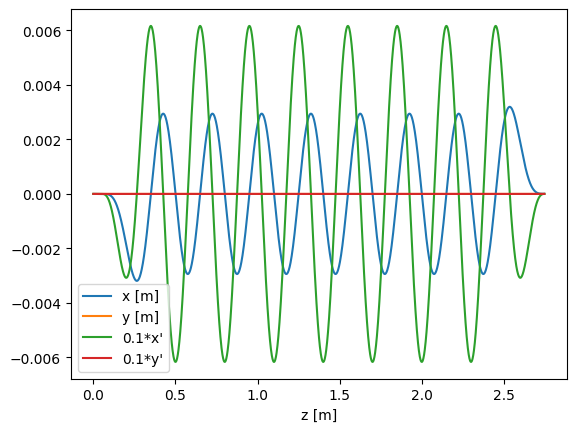

In [43]:
t = snap_data[:,0]
print(f't = ({np.min(t):.7g}, {np.max(t):.7g}) s')

x = snap_data[:,1]
y = snap_data[:,2]
z = snap_data[:,3]
print(f'z = ({np.min(z):.7g}, {np.max(z):.7g}) m')

xp = snap_data[:,4] / snap_data[:,6]
yp = snap_data[:,5] / snap_data[:,6]

plt.plot(z,x, label='x [m]')
plt.plot(z,y, label='y [m]')
plt.plot(z,0.1*xp, label="0.1*x'")
plt.plot(z,0.1*yp, label="0.1*y'")
plt.xlabel('z [m]')
plt.legend()
plt.show()

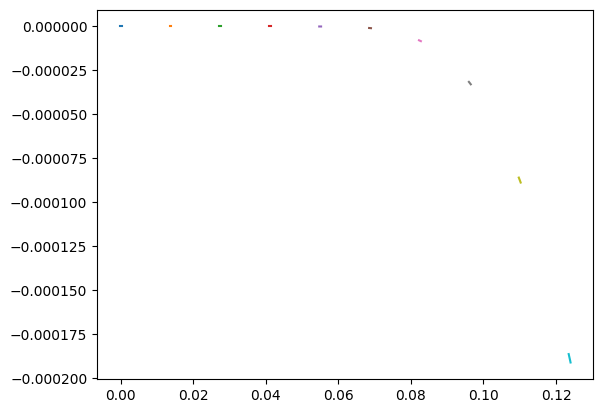

In [48]:
for i in range(0,100,10):
    slc = slice_data[i,:,:]
    z_list = slc[:,5]
    x_list = slc[:,3]
    plt.plot(z_list,x_list)
plt.show()

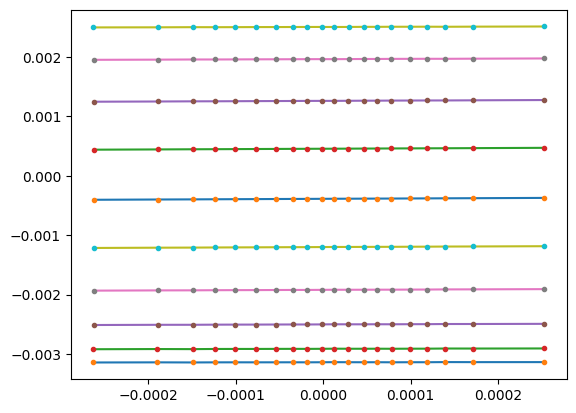

In [49]:
for i in range(200,300,10):
    slc = slice_data[i,:,:]
    z_list = slc[:,5]
    z_center = snap_data[i,3]
    x_list = slc[:,3]
    plt.plot(z_list-z_center,x_list)
    plt.plot(z_list-z_center,x_list, '.')
plt.show()

In [51]:
slice_s_min = slice_data[200,:,0]
slice_s_max = slice_data[200,:,1]
print(slice_s_min)
print(slice_s_max)
slice_lengths = slice_s_max - slice_s_min
print(slice_lengths)
print(slice_lengths.sum())

[-4.05612961e-04 -2.17846718e-04 -1.65867472e-04 -1.34904917e-04
 -1.12959722e-04 -8.81916487e-05 -6.37541367e-05 -4.19651547e-05
 -2.61839450e-05 -9.77129518e-06  6.64503140e-06  2.05817137e-05
  3.98668328e-05  5.53506223e-05  6.81763941e-05  8.86911657e-05
  1.09193831e-04  1.30312565e-04  1.54526503e-04  1.91188508e-04]
[-2.19111686e-04 -1.66465545e-04 -1.35057885e-04 -1.13580709e-04
 -8.89514348e-05 -6.37618770e-05 -4.28682319e-05 -2.67025455e-05
 -1.04928842e-05  6.60491608e-06  1.96665153e-05  3.95752614e-05
  5.52489123e-05  6.79947166e-05  8.84719970e-05  1.09045275e-04
  1.29164477e-04  1.51873009e-04  1.90422164e-04  4.02495881e-04]
[1.86501275e-04 5.13811726e-05 3.08095875e-05 2.13242075e-05
 2.40082874e-05 2.44297717e-05 2.08859047e-05 1.52626093e-05
 1.56910608e-05 1.63762113e-05 1.30214839e-05 1.89935477e-05
 1.53820794e-05 1.26440943e-05 2.02956029e-05 2.03541097e-05
 1.99706462e-05 2.15604444e-05 3.58956609e-05 2.11307373e-04]
0.0007960951300657532
